In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install ultralytics -q

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 51.3 MB/s eta 0:00:00


In [ ]:
!cp -r /content/drive/MyDrive/custom_data /content/custom_data
print("✅ Copy done!")

In [6]:
# Step 2 — Fix yaml to point to local path
import yaml

yaml_path = '/content/custom_data/data.yaml'

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

data['path'] = '/content/custom_data'
data['train'] = 'train/images'
data['val']   = 'valid/images'
data['test']  = 'test/images'

with open(yaml_path, 'w') as f:
    yaml.dump(data, f, sort_keys=False)

print("✅ YAML updated!")

✅ YAML updated!


In [7]:
# Step 3 — Train locally (much faster)
!yolo detect train \
  data=/content/custom_data/data.yaml \
  model=yolo11s.pt \
  epochs=50 \
  imgsz=640 \
  batch=16 \
  patience=15 \
  cache=True \
  project=/content/custom_data \
  name=my_model \
  exist_ok=True

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/custom_data/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=my_model, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=15

In [8]:
!yolo detect val \
  model=/content/custom_data/my_model/weights/best.pt \
  data=/content/custom_data/data.yaml \
  split=test

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 16.6±16.4 MB/s, size: 61.1 KB)
val: Scanning /content/custom_data/test/labels... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 418.9it/s 0.1s
val: New cache created: /content/custom_data/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.6it/s 1.8s
                   all         35         70        0.9      0.839        0.9      0.727
              improper         25         29      0.943      0.897      0.915       0.73
                proper         23         41      0.858       0.78      0.885      0.723
Speed: 13.0ms preprocess, 18.5ms inference, 0.0ms loss, 3.1ms postprocess per image
Results saved to /content/runs/detect/val
💡 Learn more at https://docs.ultralytics.com/

In [9]:
!yolo detect predict \
  model=/content/custom_data/my_model/weights/best.pt \
  source=/content/custom_data/test/images \
  save=True \
  conf=0.25 \
  project=/content/custom_data \
  name=predictions

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs

image 1/35 /content/custom_data/test/images/tertib167_jpg.rf.0a6c9caca21d2d26f89c74a330bfe687.jpg: 640x640 2 propers, 14.7ms
image 2/35 /content/custom_data/test/images/tertib169_jpg.rf.e42ae26b2242697873ea3823b462202d.jpg: 640x640 2 propers, 14.6ms
image 3/35 /content/custom_data/test/images/tertib197_jpg.rf.1846627f2e0fdcdab23b458307fe2c9c.jpg: 640x640 1 proper, 15.1ms
image 4/35 /content/custom_data/test/images/tertib248_jpg.rf.2a758b06f4116716e53e3827c02a4216.jpg: 640x640 4 propers, 15.5ms
image 5/35 /content/custom_data/test/images/tertib249_jpg.rf.d9c5cf066e137b7f93408b954f8f50e0.jpg: 640x640 3 propers, 15.5ms
image 6/35 /content/custom_data/test/images/tertib264_jpg.rf.f68ac14db087d72cfb8653d31bae108f.jpg: 640x640 5 propers, 15.5ms
image 7/35 /content/custom_data/test/images/tertib336_jpg.rf.b1eb2450478acddc58778a

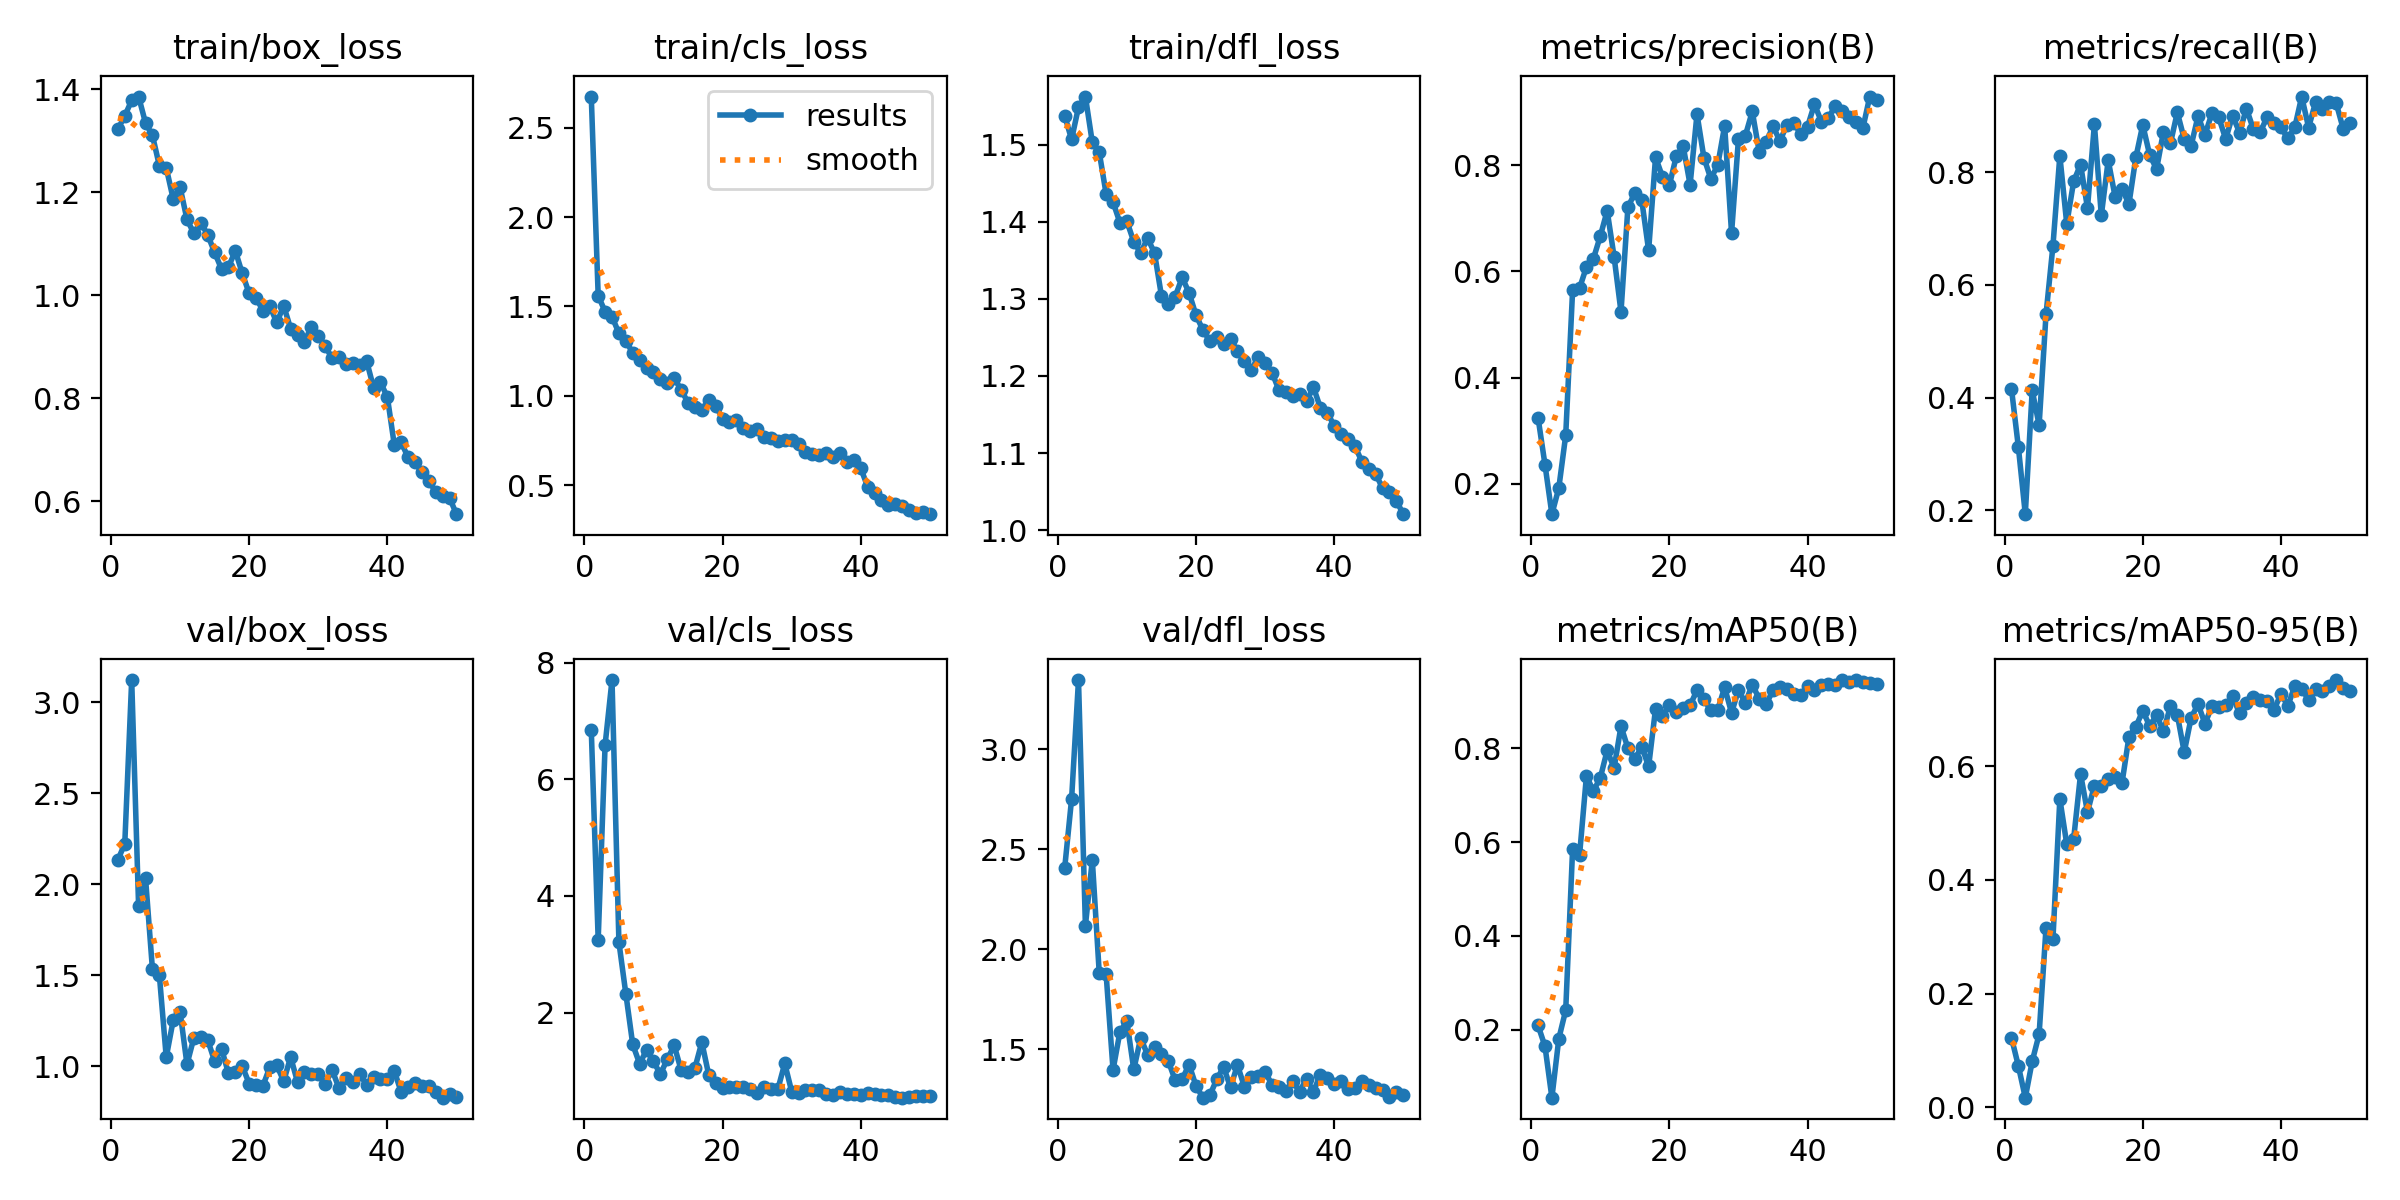

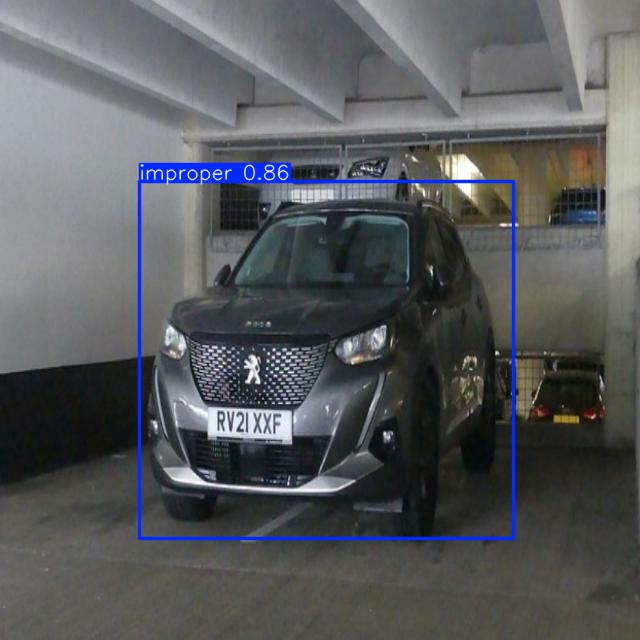

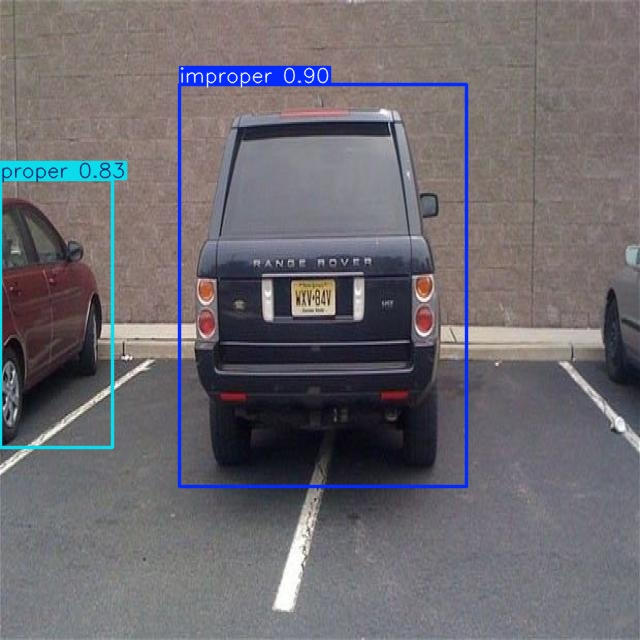

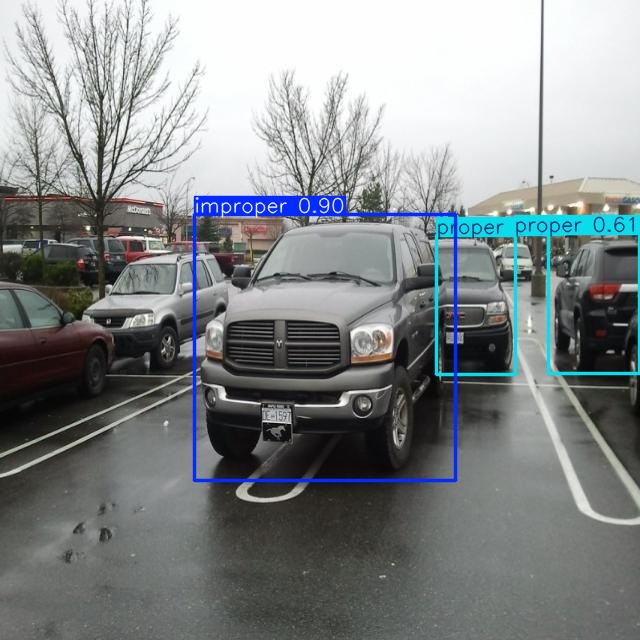

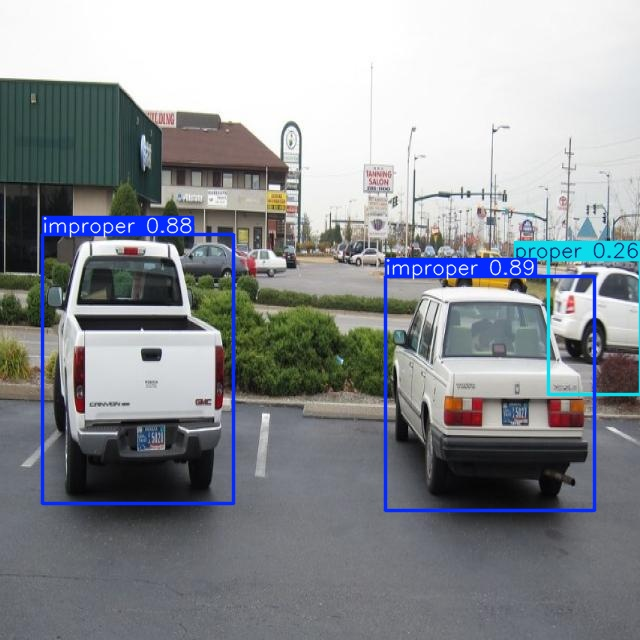

In [10]:
from IPython.display import Image, display
import glob

# Show training curves
display(Image('/content/custom_data/my_model/results.png'))

# Show a few predictions
pred_images = glob.glob('/content/custom_data/predictions/*.jpg')[:4]
for img in pred_images:
    display(Image(img, width=500))

In [11]:
from google.colab import files

# Download only best.pt (small, fast)
files.download('/content/custom_data/my_model/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Test

In [20]:
from google.colab import files
from IPython.display import Image, display
import os

# Upload your images
uploaded = files.upload()

# Save uploaded files to a test folder
os.makedirs('/content/my_test_images', exist_ok=True)
for filename in uploaded.keys():
    os.rename(filename, f'/content/my_test_images/{filename}')

print(f"✅ Uploaded {len(uploaded)} image(s)")

Saving download (4).jfif to download (4).jfif
✅ Uploaded 1 image(s)


In [21]:
!yolo detect predict \
  model=/content/custom_data/my_model/weights/best.pt \
  source=/content/my_test_images \
  save=True \
  conf=0.25 \
  project=/content \
  name=my_test_results \
  exist_ok=True

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs

image 1/2 /content/my_test_images/download (3).png: 480x640 1 improper, 60.8ms
image 2/2 /content/my_test_images/download (5).png: 384x640 1 improper, 2 propers, 60.6ms
Speed: 3.4ms preprocess, 60.7ms inference, 10.2ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/my_test_results
💡 Learn more at https://docs.ultralytics.com/modes/predict


✅ Showing 2 result(s):

/content/my_test_results/download (3).jpg


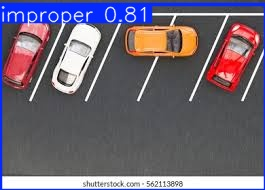

/content/my_test_results/download (5).jpg


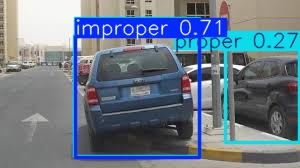

In [22]:
import glob
from IPython.display import Image, display

results = glob.glob('/content/my_test_results/*.jpg') + \
          glob.glob('/content/my_test_results/*.png')

if not results:
    print("❌ No results found — check if detection ran correctly")
else:
    print(f"✅ Showing {len(results)} result(s):\n")
    for img_path in results:
        print(img_path)
        display(Image(img_path, width=600))